In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
sample_sub_df = pd.read_csv("../data/sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_sub_df.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


In [3]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [8]:
train_df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [9]:
cat_cols = [col for col in train_df.columns if train_df[col].dtype == "O"]
num_cols = [col for col in train_df.columns if train_df[col].dtype != "O"]

print("Number of categorical colons:", len(cat_cols))
print("Number of numerical columns:", len(num_cols))


Number of categorical colons: 43
Number of numerical columns: 38


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.8828757597682129


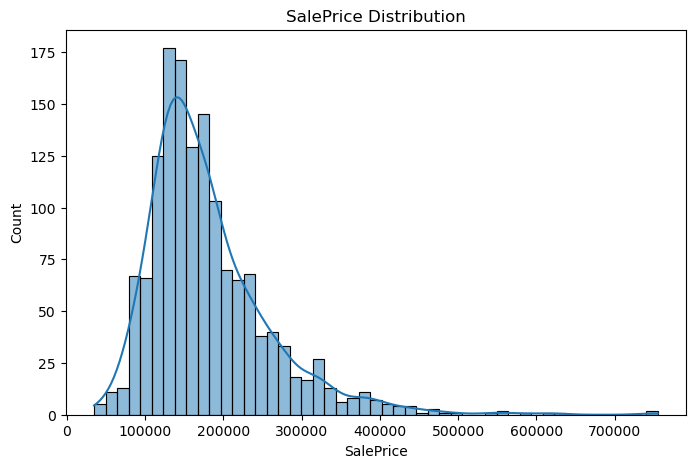

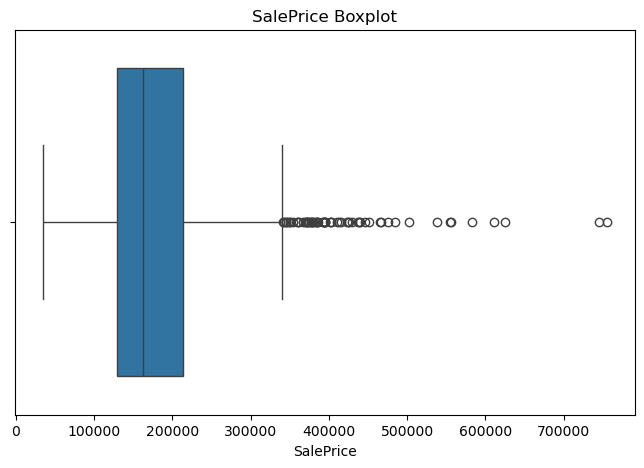

In [10]:
print(train_df["SalePrice"].describe())
print("Skewness:", train_df["SalePrice"].skew())

plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=train_df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

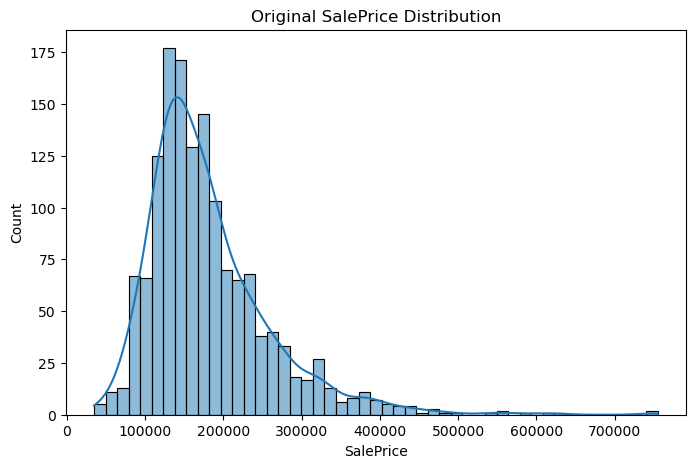

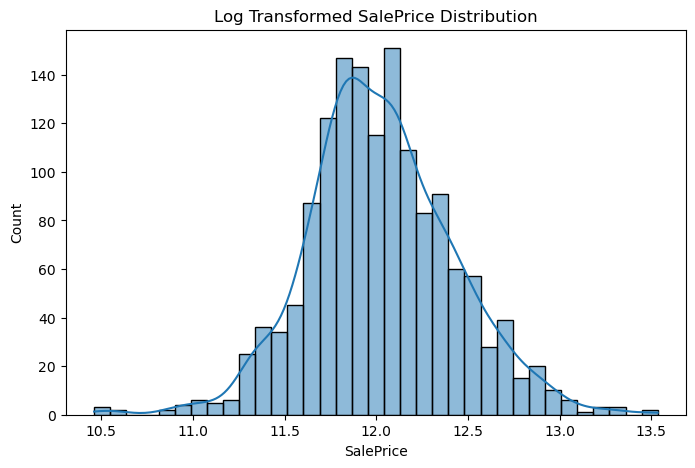

Original skewness: 1.8828757597682129
Log transformed skewness: 0.12134661989685333


In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("Original SalePrice Distribution")
plt.show()

saleprice_log = np.log1p(train_df["SalePrice"])

plt.figure(figsize=(8, 5))
sns.histplot(saleprice_log, kde=True)
plt.title("Log Transformed SalePrice Distribution")
plt.show()

print("Original skewness:", train_df["SalePrice"].skew())
print("Log transformed skewness:", saleprice_log.skew())

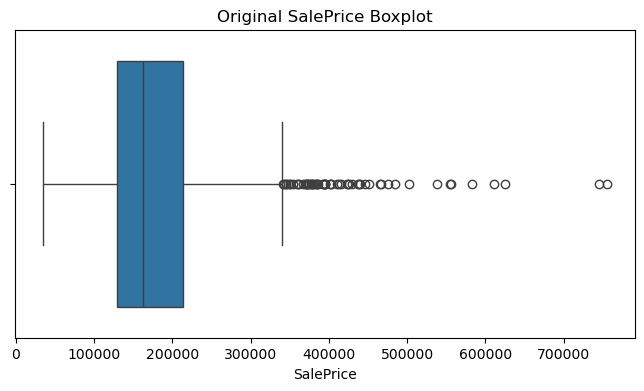

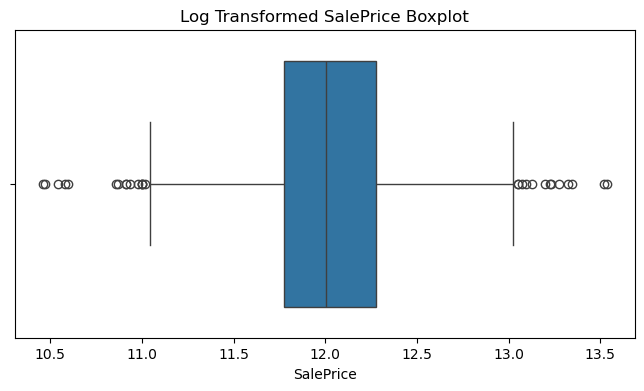

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df["SalePrice"])
plt.title("Original SalePrice Boxplot")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=saleprice_log)
plt.title("Log Transformed SalePrice Boxplot")
plt.show()

In [13]:
train_df["SalePrice_log"] = np.log1p(train_df["SalePrice"])

In [14]:
missing_df = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_ratio": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(by="missing_ratio", ascending=False)
missing_df

,missing_count,missing_ratio
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [15]:
missing_df.head(20)

,missing_count,missing_ratio
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [16]:
train_df[train_df["GarageType"].isnull()][
    ["GarageType", "GarageFinish", "GarageQual", "GarageCond", "GarageYrBlt", "GarageCars", "GarageArea"]
].head(10)

,GarageType,GarageFinish,GarageQual,GarageCond,GarageYrBlt,GarageCars,GarageArea
39,NaN,NaN,NaN,NaN,NaN,0,0
48,NaN,NaN,NaN,NaN,NaN,0,0
78,NaN,NaN,NaN,NaN,NaN,0,0
88,NaN,NaN,NaN,NaN,NaN,0,0
89,NaN,NaN,NaN,NaN,NaN,0,0
99,NaN,NaN,NaN,NaN,NaN,0,0
108,NaN,NaN,NaN,NaN,NaN,0,0
125,NaN,NaN,NaN,NaN,NaN,0,0
127,NaN,NaN,NaN,NaN,NaN,0,0
140,NaN,NaN,NaN,NaN,NaN,0,0


In [17]:
train_df[train_df["BsmtQual"].isnull()][
    ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2"]
].head(10)

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,BsmtFinSF1,BsmtFinSF2
17,NaN,NaN,NaN,NaN,NaN,0,0,0
39,NaN,NaN,NaN,NaN,NaN,0,0,0
90,NaN,NaN,NaN,NaN,NaN,0,0,0
102,NaN,NaN,NaN,NaN,NaN,0,0,0
156,NaN,NaN,NaN,NaN,NaN,0,0,0
182,NaN,NaN,NaN,NaN,NaN,0,0,0
259,NaN,NaN,NaN,NaN,NaN,0,0,0
342,NaN,NaN,NaN,NaN,NaN,0,0,0
362,NaN,NaN,NaN,NaN,NaN,0,0,0
371,NaN,NaN,NaN,NaN,NaN,0,0,0


In [18]:
train_df2 = train_df.copy()
test_df2 = test_df.copy()

In [19]:
none_fill_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"
]

for col in none_fill_cols:
    train_df2[col] = train_df2[col].fillna("None")
    test_df2[col] = test_df2[col].fillna("None")

In [20]:
zero_fill_cols = ["MasVnrArea"]

for col in zero_fill_cols:
    train_df2[col] = train_df2[col].fillna(0)
    test_df2[col] = test_df2[col].fillna(0)

In [21]:
train_df2["Electrical"].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [22]:
mode_electrical = train_df2["Electrical"].mode()[0]

train_df2["Electrical"] = train_df2["Electrical"].fillna(mode_electrical)
test_df2["Electrical"] = test_df2["Electrical"].fillna(mode_electrical)

In [23]:
train_df2["Electrical"].value_counts()

Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [24]:
missing_after_step1 = pd.DataFrame({
    "missing_count": train_df2.isnull().sum(),
    "missing_ratio": (train_df2.isnull().sum() / len(train_df2)) * 100
})

missing_after_step1 = missing_after_step1[missing_after_step1["missing_count"] > 0].sort_values(
    by="missing_ratio", ascending=False
)

missing_after_step1

,missing_count,missing_ratio
MasVnrType,872,59.726027
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945


In [25]:
train_df2["GarageYrBlt"].value_counts()

GarageYrBlt
2005.0    65
2006.0    59
2004.0    53
2003.0    50
2007.0    49
          ..
1927.0     1
1900.0     1
1906.0     1
1908.0     1
1933.0     1
Name: count, Length: 97, dtype: int64

In [26]:
train_df2["HasGarage"] = np.where(train_df2["GarageArea"] > 0, 1, 0)
test_df2["HasGarage"] = np.where(test_df2["GarageArea"] > 0, 1, 0)

In [27]:
train_df2["GarageYrBlt"] = train_df2["GarageYrBlt"].fillna(train_df2["GarageYrBlt"].median())
test_df2["GarageYrBlt"] = test_df2["GarageYrBlt"].fillna(test_df2["GarageYrBlt"].median())

In [28]:
train_df2["MasVnrType"] = train_df2["MasVnrType"].fillna("None")
test_df2["MasVnrType"] = test_df2["MasVnrType"].fillna("None")

In [29]:
train_df2["LotFrontage"] = train_df2.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

test_df2["LotFrontage"] = test_df2.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [30]:
train_df2["LotFrontage"] = train_df2["LotFrontage"].fillna(train_df2["LotFrontage"].median())
test_df2["LotFrontage"] = test_df2["LotFrontage"].fillna(test_df2["LotFrontage"].median())

In [31]:
pd.DataFrame({
    "missing_count": train_df2.isnull().sum(),
    "missing_ratio": (train_df2.isnull().sum() / len(train_df2)) * 100
}).query("missing_count > 0").sort_values("missing_ratio", ascending=False)

,missing_count,missing_ratio


In [32]:
pd.DataFrame({
    "missing_count": test_df2.isnull().sum(),
    "missing_ratio": (test_df2.isnull().sum() / len(test_df2)) * 100
}).query("missing_count > 0").sort_values("missing_ratio", ascending=False)

,missing_count,missing_ratio
MSZoning,4,0.27416
Utilities,2,0.13708
BsmtFullBath,2,0.13708
BsmtHalfBath,2,0.13708
Functional,2,0.13708
Exterior1st,1,0.06854
Exterior2nd,1,0.06854
BsmtFinSF1,1,0.06854
BsmtFinSF2,1,0.06854
BsmtUnfSF,1,0.06854


In [33]:
test_cat_fill_cols = [
    "MSZoning", "Utilities", "Functional",
    "Exterior1st", "Exterior2nd", "KitchenQual", "SaleType"
]

for col in test_cat_fill_cols:
    test_df2[col] = test_df2[col].fillna(test_df2[col].mode()[0])

In [34]:
test_num_fill_cols = [
    "BsmtFullBath", "BsmtHalfBath",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "GarageCars", "GarageArea"
]

for col in test_num_fill_cols:
    test_df2[col] = test_df2[col].fillna(test_df2[col].median())

In [35]:
pd.DataFrame({
    "missing_count": test_df2.isnull().sum(),
    "missing_ratio": (test_df2.isnull().sum() / len(test_df2)) * 100
}).query("missing_count > 0").sort_values("missing_ratio", ascending=False)

,missing_count,missing_ratio


In [36]:
train_df2["SalePrice_log"] = np.log1p(train_df2["SalePrice"])

In [37]:
corr_matrix = train_df2.corr(numeric_only=True)

saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
print(saleprice_corr.head(15))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
Name: SalePrice, dtype: float64


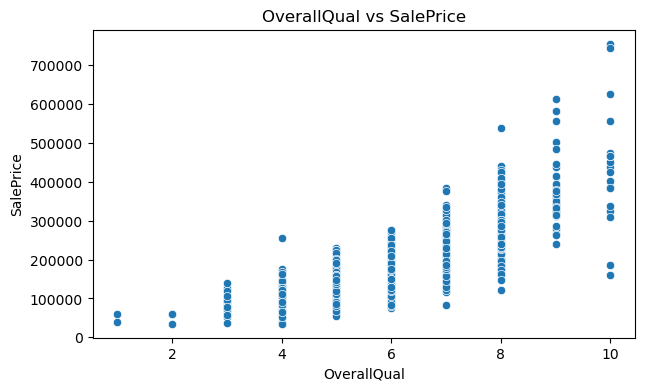

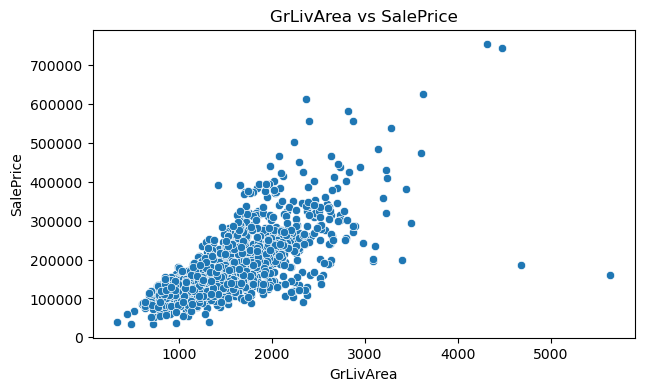

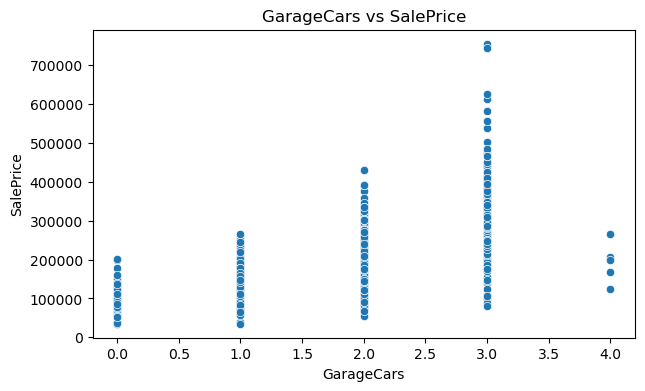

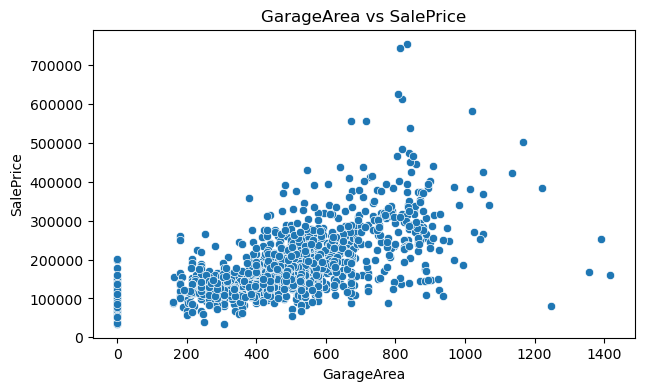

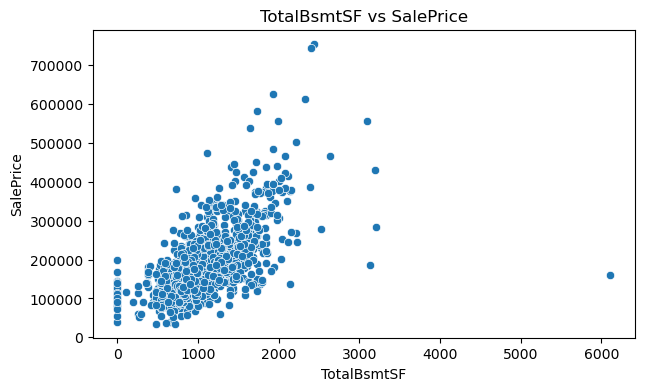

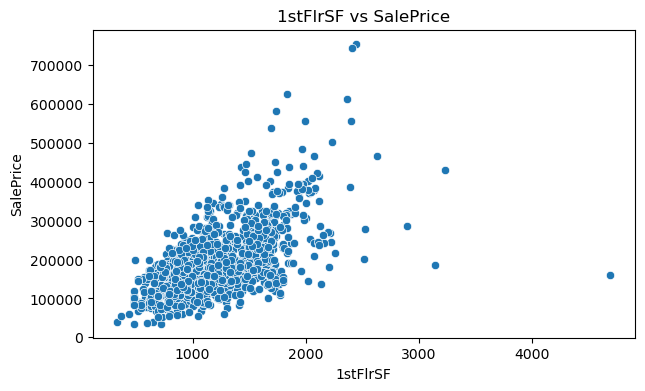

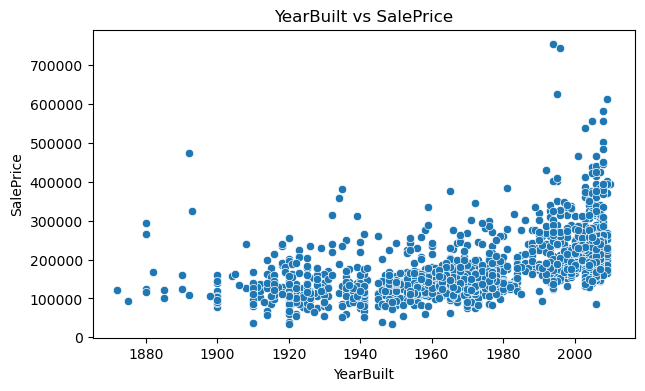

In [38]:
important_num_cols = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "YearBuilt"
]

for col in important_num_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=train_df2[col], y=train_df2["SalePrice"])
    plt.title(f"{col} vs SalePrice")
    plt.show()

In [39]:
train_df2[train_df2["GrLivArea"] > 4000][["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]].sort_values(
    by="GrLivArea", ascending=False
)

,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,5642,160000,10,Edwards
523,4676,184750,10,Edwards
1182,4476,745000,10,NoRidge
691,4316,755000,10,NoRidge


In [40]:
train_df2[train_df2["TotalBsmtSF"] > 6000][["TotalBsmtSF", "SalePrice", "OverallQual", "Neighborhood"]]

,TotalBsmtSF,SalePrice,OverallQual,Neighborhood
1298,6110,160000,10,Edwards


In [41]:
train_df2[train_df2["GarageArea"] > 1200][["GarageArea", "GarageCars", "SalePrice", "OverallQual", "Neighborhood"]].sort_values(
    by="GarageArea", ascending=False
)

,GarageArea,GarageCars,SalePrice,OverallQual,Neighborhood
1298,1418,2,160000,10,Edwards
581,1390,3,253293,8,NridgHt
1190,1356,4,168000,4,Mitchel
1061,1248,3,81000,3,IDOTRR
825,1220,3,385000,10,NridgHt


In [42]:
print("Before removing outliers:", train_df2.shape)

Before removing outliers: (1460, 83)


In [43]:
train_df2 = train_df2[~((train_df2["GrLivArea"] > 4000) & (train_df2["SalePrice"] < 300000))]

In [44]:
print("After removing outliers:", train_df2.shape)

After removing outliers: (1458, 83)


In [45]:
train_df2["HouseAge"] = train_df2["YrSold"] - train_df2["YearBuilt"]
test_df2["HouseAge"] = test_df2["YrSold"] - test_df2["YearBuilt"]

In [46]:
train_df2["RemodAge"] = train_df2["YrSold"] - train_df2["YearRemodAdd"]
test_df2["RemodAge"] = test_df2["YrSold"] - test_df2["YearRemodAdd"]

In [47]:
train_df2["TotalSF"] = train_df2["TotalBsmtSF"] + train_df2["1stFlrSF"] + train_df2["2ndFlrSF"]
test_df2["TotalSF"] = test_df2["TotalBsmtSF"] + test_df2["1stFlrSF"] + test_df2["2ndFlrSF"]

In [48]:
train_df2["TotalBath"] = (
    train_df2["FullBath"] +
    0.5 * train_df2["HalfBath"] +
    train_df2["BsmtFullBath"] +
    0.5 * train_df2["BsmtHalfBath"]
)

test_df2["TotalBath"] = (
    test_df2["FullBath"] +
    0.5 * test_df2["HalfBath"] +
    test_df2["BsmtFullBath"] +
    0.5 * test_df2["BsmtHalfBath"]
)

In [49]:
train_df2["HasFireplace"] = np.where(train_df2["Fireplaces"] > 0, 1, 0)
test_df2["HasFireplace"] = np.where(test_df2["Fireplaces"] > 0, 1, 0)

In [50]:
train_df2["HasBsmt"] = np.where(train_df2["TotalBsmtSF"] > 0, 1, 0)
test_df2["HasBsmt"] = np.where(test_df2["TotalBsmtSF"] > 0, 1, 0)

In [51]:
train_df2[["HouseAge", "RemodAge", "TotalSF", "TotalBath", "HasGarage", "HasFireplace", "HasBsmt"]].head()

,HouseAge,RemodAge,TotalSF,TotalBath,HasGarage,HasFireplace,HasBsmt
0,5,5,2566,3.5,1,0,1
1,31,31,2524,2.5,1,1,1
2,7,6,2706,3.5,1,1,1
3,91,36,2473,2.0,1,1,1
4,8,8,3343,3.5,1,1,1


In [52]:
new_features = [
    "HouseAge", "RemodAge", "TotalSF",
    "TotalBath", "HasGarage", "HasFireplace", "HasBsmt"
]

print(train_df2[new_features + ["SalePrice"]].corr(numeric_only=True)["SalePrice"].sort_values(ascending=False))

SalePrice       1.000000
TotalSF         0.832877
TotalBath       0.635896
HasFireplace    0.472350
HasGarage       0.236883
HasBsmt         0.152860
RemodAge       -0.509706
HouseAge       -0.524067
Name: SalePrice, dtype: float64


In [53]:
train_df2["SalePrice_log"] = np.log1p(train_df2["SalePrice"])

X = train_df2.drop(["SalePrice", "SalePrice_log"], axis=1)
y = train_df2["SalePrice_log"]

X_test = test_df2.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1458, 87)
y shape: (1458,)
X_test shape: (1459, 87)


In [54]:
combined = pd.concat([X, X_test], axis=0)

combined_encoded = pd.get_dummies(combined, drop_first=True)

X_encoded = combined_encoded.iloc[:len(X), :]
X_test_encoded = combined_encoded.iloc[len(X):, :]

print("Encoded X shape:", X_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X shape: (1458, 266)
Encoded X_test shape: (1459, 266)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=15
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1166, 266)
X_test: (292, 266)
y_train: (1166,)
y_test: (292,)


In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

Linear Regression RMSE: 0.12140877920250294
Linear Regression R2: 0.8983380994251509


In [57]:
from sklearn.linear_model import  Ridge, Lasso, ElasticNet

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.0005),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.9)
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

C:\Users\Umut Cetin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.321e+00, tolerance: 1.902e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Umut Cetin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.238e+00, tolerance: 1.902e-02
  model = cd_fast.enet_coordinate_descent(


,Model,RMSE,R2
1,Ridge,0.116429,0.906507
2,Lasso,0.116781,0.905941
3,ElasticNet,0.116794,0.905919
0,LinearRegression,0.121409,0.898338


In [58]:
from sklearn.model_selection import cross_val_score, KFold

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.0005),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.9)
}

cv_results = []

cv = KFold(n_splits=5, shuffle=True, random_state=15)

for model_name, model in models.items():
    rmse_scores = np.sqrt(-cross_val_score(
        model,
        X_encoded,
        y,
        cv=cv,
        scoring="neg_mean_squared_error"
    ))

    cv_results.append({
        "Model": model_name,
        "CV_RMSE_Mean": rmse_scores.mean(),
        "CV_RMSE_Std": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE_Mean")
cv_results_df

C:\Users\Umut Cetin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.321e+00, tolerance: 1.902e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Umut Cetin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.345e+00, tolerance: 1.881e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Umut Cetin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.48

,Model,CV_RMSE_Mean,CV_RMSE_Std
1,Ridge,0.114873,0.006322
3,ElasticNet,0.115252,0.006428
2,Lasso,0.115260,0.006383
0,LinearRegression,0.124342,0.006905


In [59]:
from sklearn.model_selection import GridSearchCV

ridge_model = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_params,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_encoded, y)

print("Best Params:", ridge_grid.best_params_)
print("Best Score (neg MSE):", ridge_grid.best_score_)

best_ridge_rmse = np.sqrt(-ridge_grid.best_score_)
print("Best CV RMSE:", best_ridge_rmse)

Best Params: {'alpha': 10}
Best Score (neg MSE): -0.013497168559860143
Best CV RMSE: 0.11617731516892678


In [60]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

tree_models = {
    "Ridge": Ridge(alpha=10),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=15,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=15
    )
}

tree_results = []

for model_name, model in tree_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    tree_results.append({
        "Model": model_name,
        "RMSE": rmse,
        "R2": r2
    })

tree_results_df = pd.DataFrame(tree_results).sort_values(by="RMSE")
tree_results_df

,Model,RMSE,R2
0,Ridge,0.116429,0.906507
2,GradientBoosting,0.124319,0.893406
1,RandomForest,0.138719,0.867281


In [61]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [62]:
boost_models = {
    "Ridge": Ridge(alpha=10),
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=15,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=15,
        n_jobs=-1
    )
}

boost_results = []

for model_name, model in boost_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    boost_results.append({
        "Model": model_name,
        "RMSE": rmse,
        "R2": r2
    })

boost_results_df = pd.DataFrame(boost_results).sort_values(by="RMSE")
boost_results_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3835
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 175
[LightGBM] [Info] Start training from score 12.030320


,Model,RMSE,R2
0,Ridge,0.116429,0.906507
1,XGBoost,0.120346,0.900110
2,LightGBM,0.127755,0.887433


In [63]:
cv = KFold(n_splits=5, shuffle=True, random_state=15)

cv_models = {
    "Ridge": Ridge(alpha=10),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=15,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=15,
        n_jobs=-1,
        verbose=-1
    )
}

cv_boost_results = []

for model_name, model in cv_models.items():
    rmse_scores = np.sqrt(-cross_val_score(
        model,
        X_encoded,
        y,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    ))

    cv_boost_results.append({
        "Model": model_name,
        "CV_RMSE_Mean": rmse_scores.mean(),
        "CV_RMSE_Std": rmse_scores.std()
    })

cv_boost_results_df = pd.DataFrame(cv_boost_results).sort_values(by="CV_RMSE_Mean")
cv_boost_results_df

,Model,CV_RMSE_Mean,CV_RMSE_Std
0,Ridge,0.114873,0.006322
1,XGBoost,0.117976,0.008799
2,LightGBM,0.124440,0.007501


In [64]:
xgb_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0, 5.0]
}

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=15,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_encoded, y)

print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost Best CV RMSE:", np.sqrt(-xgb_grid.best_score_))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
XGBoost Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'reg_lambda': 5.0, 'subsample': 0.8}
XGBoost Best CV RMSE: 0.11721435717737327


In [65]:
lgbm_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.0, 1.0, 3.0]
}

lgbm_model = LGBMRegressor(
    random_state=15,
    n_jobs=-1,
    verbose=-1
)

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_encoded, y)

print("LightGBM Best Params:", lgbm_grid.best_params_)
print("LightGBM Best CV RMSE:", np.sqrt(-lgbm_grid.best_score_))

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
LightGBM Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 800, 'num_leaves': 15, 'reg_lambda': 0.0, 'subsample': 0.8}
LightGBM Best CV RMSE: 0.11887068579945434


In [66]:
final_ridge = Ridge(alpha=10)
final_ridge.fit(X_encoded, y)

test_pred_log = final_ridge.predict(X_test_encoded)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred
})

print(submission.shape)
print(submission.head())
print(submission["SalePrice"].describe())

submission.to_csv("ridge_submission.csv", index=False)

(1459, 2)
     Id      SalePrice
0  1461  113676.073535
1  1462  151488.286434
2  1463  178672.576809
3  1464  199828.005008
4  1465  189557.310293
count    1.459000e+03
mean     1.774322e+05
std      8.785076e+04
min      5.047417e+04
25%      1.237605e+05
50%      1.546458e+05
75%      2.074476e+05
max      1.718402e+06
Name: SalePrice, dtype: float64


In [67]:
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd

final_ridge = Ridge(alpha=10)
final_ridge.fit(X_encoded, y)

test_pred_log = final_ridge.predict(X_test_encoded)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred
})

submission.head()

,Id,SalePrice
0,1461,113676.073535
1,1462,151488.286434
2,1463,178672.576809
3,1464,199828.005008
4,1465,189557.310293


In [68]:
submission.to_csv("../outputs/ridge_submission.csv", index=False)

Final Conclusion

The objective of this work was to predict the house sale prices using the Kaggle House Prices: Advanced Regression Techniques dataset. The project involved multiple steps from data cleaning, missing values treatment, outliers detection and deletion, feature creation, target transformation and encoding, up to the model selection.

Specific techniques for different types of missing values were used for their treatment and two outliers that appeared to be inconsistent were deleted based on the analysis of correlation between the living area and the sale price. The target variable SalePrice showed significant skewness; therefore, log1p transformation was used.

Additional features (TotalSF, TotalBath, HouseAge, and RemodAge) were created to increase the explanatory power of the dataset. Models such as Linear Regression, Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting, XGBoost, and LightGBM were compared.

It should be mentioned that among all models tried, Ridge Regression with alpha=10 gave the best results and it was chosen as the final model.

Final Results

Linear Regression RMSE: 0.1214
Ridge RMSE: 0.1164
Ridge Cross-Validation RMSE Mean: 0.1149